In [55]:
import numpy as np
import astropy.units as u
import astropy.constants as const
from astropy.time import Time
from astropy.coordinates import SkyCoord, CartesianRepresentation
import matplotlib.pyplot as plt
import spiceypy as spice

from light_deflection import delta_kpn, calc_CE, calc_der_E, calc_der_star, calc_CPE, calc_CO, calc_CT
from ephemeris import ephem_kernel, on_sky_velocity

In [56]:
kernel = ['/srv/jupyterhub/shared/data/kernels/jup365.bsp']

spice.furnsh(kernel)

In [57]:
# Occultation parameters
occ_time = Time('2020-12-21 00:46:00', scale='utc')

sun_spkid = '10'

G = const.G.to(u.AU**3 / u.kg / u.day**2)
sun_GM = G *  u.M_sun

In [58]:
# Geocentric positions at the reference epoch
pos_sun, vel_sun = ephem_kernel(time=occ_time, target=sun_spkid, observer='500')
pos_sun = pos_sun.cartesian

d_sun = pos_sun.norm()
pos_sun = CartesianRepresentation(d_sun, 0, 0,  unit=u.AU) #a generic position for the Sun

pos_earth = CartesianRepresentation(0 * u.km, 0 * u.km, 0 * u.km)

pos_star = SkyCoord('20h09m33.4968s -20d35m38.7271s', distance=77.8972*u.pc)
d_sg1 = 77.8972 * u.pc

In [59]:
DA_sun = pos_sun.norm()

In [60]:
spice.kclear()

In [61]:
def deflec_vecs(pos_observer, pos_source, pos_massive, gm):
    vec_rso = pos_observer - pos_source
    vec_rao = pos_observer - pos_massive
    vec_ras = pos_source - pos_massive
    return delta_kpn(gm=gm, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

In [62]:
def astrometric_corrections_vs_target_distance(name, massive_pos, gm_massive, observer,
                                                   source_distance, target_distances,
                                                   angular_separations):
    colors = plt.cm.tab10(np.linspace(0, 1, len(angular_separations)))
    results = {}
    fig, ax = plt.subplots()

    line_styles = ['-', '-.', ':', '--', '-', '-.', ':', '--', '-', '-.']
    line_widths = [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
    markers = [None, None, None, None, None, None, None, None, None, None]

    for i, separation in enumerate(angular_separations):
        distances_to_target = []
        astrometric_correctionss = []

        theta_massive_star = separation.to(u.rad).value
        source_distance_au = source_distance.to(u.AU).value

        vec_massive_observer = massive_pos - observer
        coord_massive_observer = SkyCoord(vec_massive_observer)
        theta_massive_earth = np.arctan2(coord_massive_observer.cartesian.y.value,
                                          coord_massive_observer.cartesian.x.value)
        theta_source = theta_massive_earth + theta_massive_star

        X_source = source_distance_au * np.cos(theta_source)
        Y_source = source_distance_au * np.sin(theta_source)
        source_observer = CartesianRepresentation(X_source, Y_source, 0) * u.AU

        for distance in target_distances:
            X_target = distance * np.cos(theta_source)
            Y_target = distance * np.sin(theta_source)
            target_observer = CartesianRepresentation(X_target, Y_target, 0 * u.AU)

            deflection_target = deflec_vecs(observer, target_observer, massive_pos, gm_massive)
            deflection_source = deflec_vecs(observer, source_observer, massive_pos, gm_massive)

            deflection_diff = deflection_source - deflection_target
            sin_theta_diff = deflection_diff.norm().decompose()
            deflection_diff_angle = np.arcsin(sin_theta_diff)

            astrometric_corrections = target_observer.norm() * np.sin(deflection_diff_angle)

            distances_to_target.append(distance.value)
            astrometric_correctionss.append(astrometric_corrections.to(u.km).value)

        results[f'{separation} deg'] = {
            'distances_to_target': distances_to_target,
            'astrometric_correctionss': astrometric_correctionss,
        }

        ax.plot(
            distances_to_target, astrometric_correctionss,
            linestyle=line_styles[i],
            linewidth=line_widths[i],
            marker=markers[i],
            color=colors[i],
            label=f'{separation}',
        )
        ax.text(
            distances_to_target[1], astrometric_correctionss[1],
            f' {separation}',
            color=colors[i], fontsize=9,
            va='bottom', ha='left',
            rotation=24,
        )

    regions = [
        (0.1, 1.5, 'NEAs', 'red', 0.09),
        (2.06, 3.65, 'Asteroid\nMain Belt', 'blue', 0.09),
        (4.5, 5.9, 'Jupiter\nTrojans', 'green', 0.09),
        (30, 50, 'TNOs', 'purple', 0.09),
    ]

    for start, end, label, color, alpha in regions:
        ax.axvspan(start, end, alpha=alpha, color=color)
        x_center = np.sqrt(start * end)  # center on a log scale
        ax.text(
            x_center, 0.1,
            label,
            color=color, fontsize=8, ha='center', va='top',
            transform=ax.get_xaxis_transform(),
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1.5),
        )

    ax.set_xlabel('Observer-target distance, $(D_E)$ (au)', fontsize=12)
    ax.set_ylabel('Astrometric Correction, $(C_E)$ (km)', fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(0.1, 50)
    ax.set_title(f'{name}', fontsize=14)
    ax.grid(True, linestyle='--', alpha=1)
    plt.savefig('sol.pdf', bbox_inches='tight')
    plt.show()

    return results, distances_to_target, astrometric_correctionss



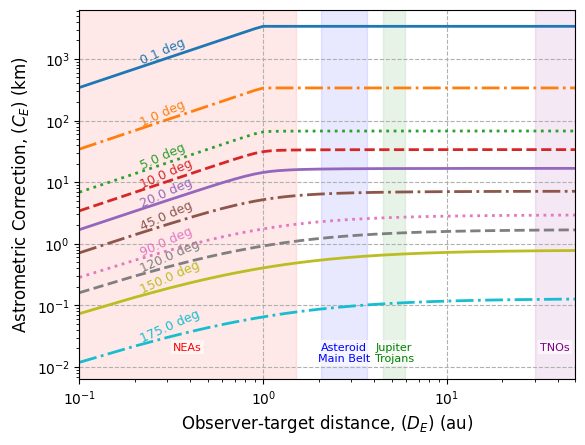

In [64]:
angular_separations = [0.1, 1, 5, 10, 20, 45, 90, 120, 150, 175] * u.deg
target_distance_grid = np.linspace(0.1, 50, 500) * u.AU

sun_graph = astrometric_corrections_vs_target_distance(
    "", pos_sun, sun_GM, pos_earth, d_sg1, target_distance_grid, angular_separations
)